<a href="https://colab.research.google.com/github/newts0fa/ml-basics/blob/main/%E2%84%966%20%D0%BF%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D0%BA%D0%B0_%D1%80%D0%B5%D1%88%D0%B0%D1%8E%D1%89%D0%B8%D0%B5_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *0. Ознакомиться с [блокнотом](https://colab.research.google.com/drive/1PwN8igT5w2xArBGmM6rvO9pVRQMh-FQn?usp=sharing)

# 1. Дерево решений для классификации  Воронов Илья Михайлович 2024-ФГИИБ-пи-1б


In [1]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

### Получение данных

Будем работать с набором данных для задачи классификации - данные по сердечно сосудистым заболеваниям, довольно стандартный набор для изучения машинного обучения, но его нет в `sklearn'e`. Поэтому скачиваем данные со стороны, с google диска.

Ссылка на google drive: https://drive.google.com/file/d/1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G


In [3]:
!wget 'https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G' -O cardio.csv

--2026-05-18 19:34:54--  https://drive.google.com/uc?export=download&id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G
Resolving drive.google.com (drive.google.com)... 172.253.147.139, 172.253.147.138, 172.253.147.100, ...
Connecting to drive.google.com (drive.google.com)|172.253.147.139|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download [following]
--2026-05-18 19:34:54--  https://drive.usercontent.google.com/download?id=1Si4EJ_RexI3Q7yZU8eLjgp4ORe_BXr4G&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 173.194.217.132, 2607:f8b0:400c:c11::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|173.194.217.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2941524 (2.8M) [application/octet-stream]
Saving to: ‘cardio.csv’

cardio.csv          100%[===================>]   2.80M  --.-KB

В задаче предалагается предсказать наличие сердечно-сосудистых заболеваний по результатам классического врачебного осмотра. Датасет сформирован 3 групп признаков:

Объективные признаки:
- Возраст (в днях)
- Рост
- Вес
- Пол

Результаты измерения:

- Артериальное давление верхнее и нижнее
- Холестерин (три группы: норма, выше нормы, значительно выше нормы)
- Глюкоза (три группы: норма, выше нормы, значительно выше нормы)

Субъективные признаки (бинарные):

- Курение
- Употребление Алкоголя
- Физическая активность

In [4]:
import pandas as pd

df = pd.read_csv('cardio.csv', sep=';')
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
full_features = ['age', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
                 'cholesterol', 'gluc', 'smoke', 'alco', 'active']
target = 'cardio'

In [6]:
df['age'] = round(df['age'] / 365)

## 1. Вводная

### 1.1 Сколько вопросов будет задано на первом этапе

Посчитайте, сколько вопросов задаст дерево решений в самый первый раз, если использовать все признаки из списка full_features.

In [7]:
question_count_full = sum(df[feature].nunique() - 1 for feature in full_features)

question_count_full

737

### 1.2 Упростите задачу

Вопросов получилось достаточно, не будет моделировать столько вопросов, а попробуем уменьшить их количество.

Возьмите только два признака: weight и gluc.
А так же возьмите только 10 первых объектов.

In [8]:
small_features = ['weight', 'gluc']
df_small = df[small_features + [target]].head(10).copy()

df_small

,weight,gluc,cardio
0,62.0,1,0
1,85.0,1,1
2,64.0,1,1
3,82.0,1,1
4,56.0,1,0
5,67.0,2,0
6,93.0,1,0
7,95.0,3,1
8,71.0,1,0
9,68.0,1,0


### 1.3 Посчитайте еще раз, сколько будет вопросов

In [9]:
question_count_small = sum(df_small[feature].nunique() - 1 for feature in small_features)

question_count_small

11

С таким количеством вопросов уже можем работать и разбираться в устройству дерева решений.

## 2. Устройство дерева решений

### 2.1 Обучите дерево решений

Обучите дерево решений из sklearn'a с атрибутом `random_state=1`.

In [10]:
X_small = df_small[small_features]
y_small = df_small[target]

tree_clf = DecisionTreeClassifier(random_state=1)
tree_clf.fit(X_small, y_small)

tree_clf

DecisionTreeClassifier(random_state=1)

### 2.2 Отрисуйте обученное дерево решений

Нарисуйте дерево решений, которое у вас получилось после обучения. Сделайте отрисовку такой, чтобы можно было понять, какие вопросы задаются

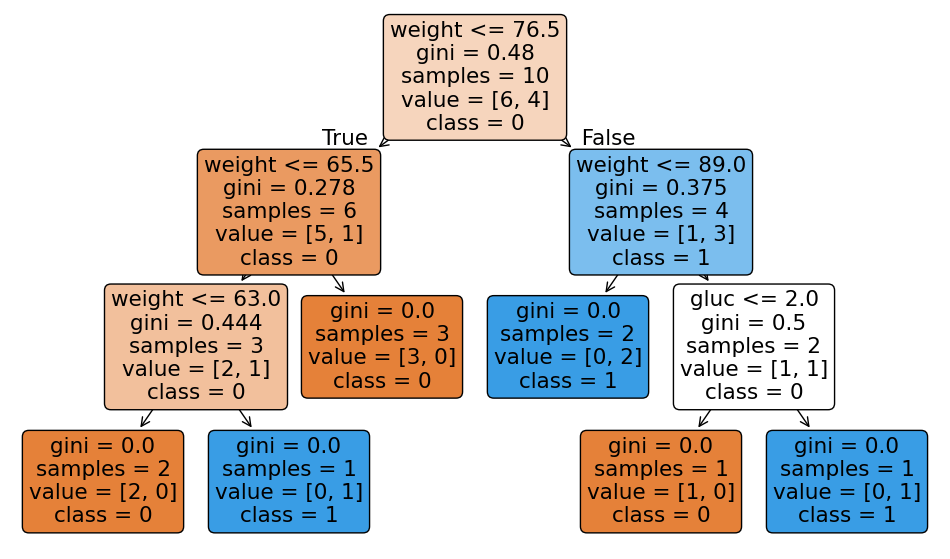

In [11]:
plt.figure(figsize=(12, 7))
plot_tree(tree_clf, feature_names=small_features, class_names=['0', '1'], filled=True, rounded=True)
plt.show()

### 2.3 Посчитайте, сколько вершин получилось

In [12]:
tree_clf.tree_.node_count

11

### 2.4 Посчитайте, сколько листов получилось

In [13]:
tree_clf.tree_.n_leaves

np.int64(6)

### 2.5 Посмотрите, почему не получилось сделать разбиение ещё на два узла в крайнем левом узле.

В узле, где
```
gini=0.5
samples=2
value=[1, 1]
```

In [14]:
left_leaf = df_small[(df_small['weight'] <= 63.5) & (df_small['gluc'] <= 1.5)]

left_leaf

,weight,gluc,cardio
0,62.0,1,0
4,56.0,1,0


## 3. Вспомогательные функции

Для того, что бы дальше сравнивать между собой объекты нужно реализовать две вспомогательные функции.

### 3.1 Функция подсчета критерия Джини

Функция должна принимать список целевых значений, считать критерий информативности и выдавать одно значение - критерий Джини.

In [15]:
def gini(y):
    values, counts = np.unique(y, return_counts=True)
    probabilities = counts / counts.sum()
    return 1 - np.sum(probabilities ** 2)

### 3.2 Проверка функции gini

Посчитайте критерий информативности в исходной выборке и вы должны получить точно такое же значение, как и было на визуализации дерева решений в его корне.

In [16]:
gini(y_small)

np.float64(0.48)

### 3.3 Функция подсчета прироста информации

Функция должна принимать целевые значения левой подвыборки, правой подвыборки и исходной вершины, а выдавать должна одно значение - прирост информации, подсчитанный на критерии информативности Джини.

In [17]:
def information_gain(y_parent, y_left, y_right):
    n_parent = len(y_parent)
    n_left = len(y_left)
    n_right = len(y_right)
    return gini(y_parent) - n_left / n_parent * gini(y_left) - n_right / n_parent * gini(y_right)

Теперь вспомогательные функции готовы можем моделировать работу обученного дерева решений.

## 4. Процесс построения дерева решений

### 4.1 Получение первого вопроса


4.1.1 Пройдитесь по всем возможным вопросам для исходного набора данных


Можете сохранять полученные значения прироста информации в датафрейм в удобную для вас структуру данных.

In [18]:
splits = []

for feature in small_features:
    values = np.sort(df_small[feature].unique())
    thresholds = (values[:-1] + values[1:]) / 2
    for threshold in thresholds:
        left = df_small[df_small[feature] <= threshold][target]
        right = df_small[df_small[feature] > threshold][target]
        splits.append({
            'feature': feature,
            'threshold': threshold,
            'gain': information_gain(y_small, left, right),
            'left_size': len(left),
            'right_size': len(right)
        })

splits_df = pd.DataFrame(splits).sort_values('gain', ascending=False)
splits_df

,feature,threshold,gain,left_size,right_size
5,weight,76.5,0.163333,6,4
4,weight,69.5,0.080000,5,5
10,gluc,2.5,0.080000,9,1
8,weight,94.0,0.080000,9,1
1,weight,63.0,0.080000,2,8
6,weight,83.5,0.060952,7,3
0,weight,59.0,0.035556,1,9
3,weight,67.5,0.030000,4,6
7,weight,89.0,0.005000,8,2
9,gluc,1.5,0.005000,8,2


4.1.2 Найдите самый лучший вопрос, опираясь на прирост информации

In [20]:
best_split = splits_df.iloc[0]

best_split

,5
feature,weight
threshold,76.5
gain,0.163333
left_size,6
right_size,4


4.1.3. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [21]:
df_left = df_small[df_small[best_split['feature']] <= best_split['threshold']]
df_right = df_small[df_small[best_split['feature']] > best_split['threshold']]

display(df_left)
display(df_right)

,weight,gluc,cardio
0,62.0,1,0
2,64.0,1,1
4,56.0,1,0
5,67.0,2,0
8,71.0,1,0
9,68.0,1,0


,weight,gluc,cardio
1,85.0,1,1
3,82.0,1,1
6,93.0,1,0
7,95.0,3,1


4.1.4. Проверьте себя через визуализацию дерева решений

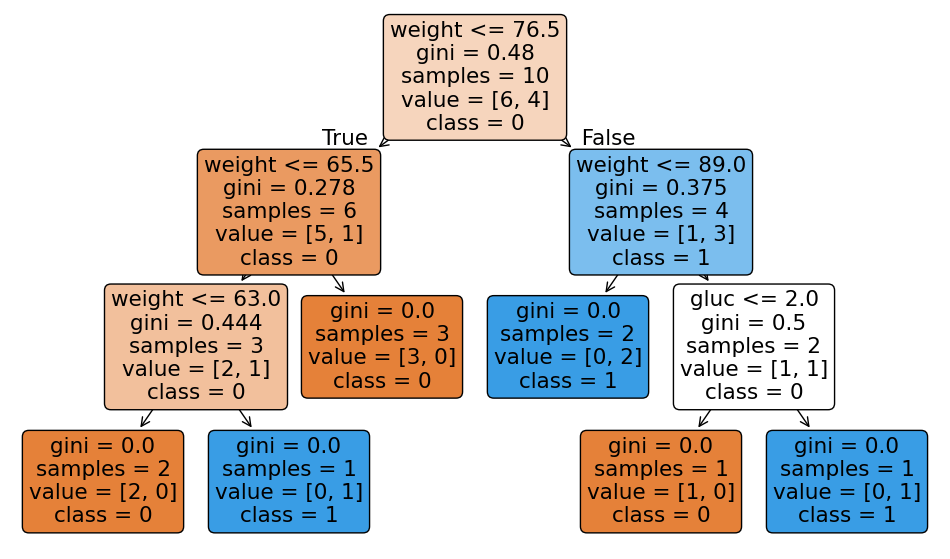

In [22]:
plt.figure(figsize=(12, 7))
plot_tree(tree_clf, feature_names=small_features, class_names=['0', '1'], filled=True, rounded=True)
plt.show()

### 4.2 Получение второго вопроса


4.2.1. Глядя на df_left и df_right, посмотрите, где можно сделать ещё разбиение

In [23]:
print('в df_left классы смешанные, значит следующее разбиение нужно искать там')
display(df_left[target].value_counts())
display(df_right[target].value_counts())

в df_left классы смешанные, значит следующее разбиение нужно искать там


,count
cardio,
0,5
1,1


,count
cardio,
1,3
0,1


4.2.2. Пройдитесь по всем признакам в выбранной подвыборке

In [24]:
second_parent = df_left.copy()
second_y = second_parent[target]

second_splits = []

for feature in small_features:
    values = np.sort(second_parent[feature].unique())
    thresholds = (values[:-1] + values[1:]) / 2
    for threshold in thresholds:
        left = second_parent[second_parent[feature] <= threshold][target]
        right = second_parent[second_parent[feature] > threshold][target]
        second_splits.append({
            'feature': feature,
            'threshold': threshold,
            'gain': information_gain(second_y, left, right),
            'left_size': len(left),
            'right_size': len(right)
        })

second_splits_df = pd.DataFrame(second_splits).sort_values('gain', ascending=False)
second_splits_df

,feature,threshold,gain,left_size,right_size
2,weight,65.5,0.055556,3,3
1,weight,63.0,0.027778,2,4
3,weight,67.5,0.027778,4,2
0,weight,59.0,0.011111,1,5
4,weight,69.5,0.011111,5,1
5,gluc,1.5,0.011111,5,1


4.2.3 Найдите самый лучший вопрос, опираясь на прирост информации

In [25]:
best_second_split = second_splits_df.iloc[0]

best_second_split

,2
feature,weight
threshold,65.5
gain,0.055556
left_size,3
right_size,3


4.2.4. Сделайте разбиение по этому вопросу исходных данных на две подвыборки df_left и df_right


In [26]:
df_left_2 = second_parent[second_parent[best_second_split['feature']] <= best_second_split['threshold']]
df_right_2 = second_parent[second_parent[best_second_split['feature']] > best_second_split['threshold']]

display(df_left_2)
display(df_right_2)

,weight,gluc,cardio
0,62.0,1,0
2,64.0,1,1
4,56.0,1,0


,weight,gluc,cardio
5,67.0,2,0
8,71.0,1,0
9,68.0,1,0


4.2.5. Проверьте себя через визуализацию дерева решений

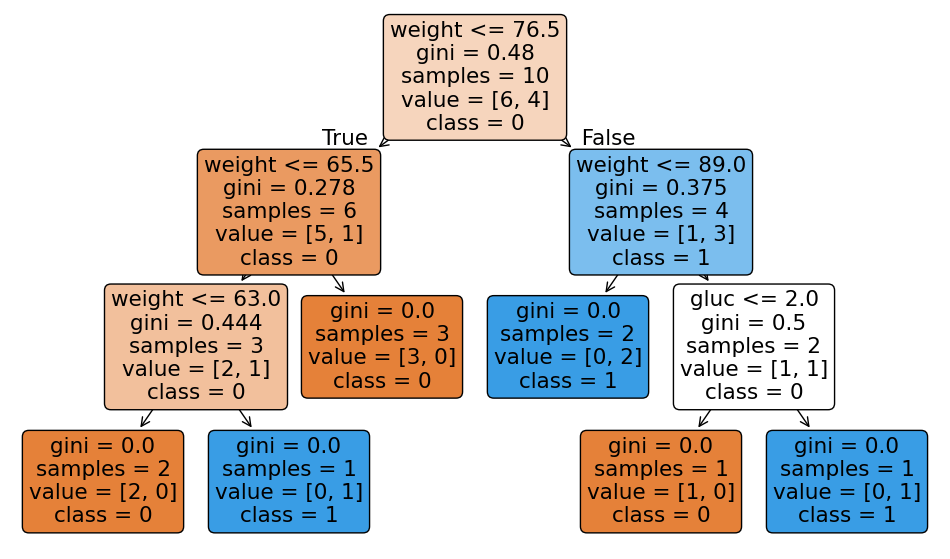

In [27]:
plt.figure(figsize=(12, 7))
plot_tree(tree_clf, feature_names=small_features, class_names=['0', '1'], filled=True, rounded=True)
plt.show()

4.2.6. Если что-то не сошлось, посмотрите, в чем может быть проблема

In [28]:
print('если порог совпал, всё сошлось. возможное отличие бывает только из-за одинаковых значений признаков и порядка выбора разбиений при равном gain')

если порог совпал, всё сошлось. возможное отличие бывает только из-за одинаковых значений признаков и порядка выбора разбиений при равном gain


# 2. Дерево решений для регрессии

In [29]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
import pandas as pd
import matplotlib.pyplot as plt

### 1. Получение данных load_breat_cancer

Будем работать с набором данных для задачи регрессии `load_diabetes`, который можно получить из стандартных датасетов в `sklearn'e`.

После `load_diabetes()` возвращается словарь с данными (`data`), целевой переменной (`target`), названиями характеристик в данных (`feature_names`) и описанием данных (`DESCR`).

In [30]:
from sklearn.datasets import load_diabetes

data = load_diabetes()
data

{'data': array([[ 0.03807591,  0.05068012,  0.06169621, ..., -0.00259226,
          0.01990749, -0.01764613],
        [-0.00188202, -0.04464164, -0.05147406, ..., -0.03949338,
         -0.06833155, -0.09220405],
        [ 0.08529891,  0.05068012,  0.04445121, ..., -0.00259226,
          0.00286131, -0.02593034],
        ...,
        [ 0.04170844,  0.05068012, -0.01590626, ..., -0.01107952,
         -0.04688253,  0.01549073],
        [-0.04547248, -0.04464164,  0.03906215, ...,  0.02655962,
          0.04452873, -0.02593034],
        [-0.04547248, -0.04464164, -0.0730303 , ..., -0.03949338,
         -0.00422151,  0.00306441]]),
 'target': array([151.,  75., 141., 206., 135.,  97., 138.,  63., 110., 310., 101.,
         69., 179., 185., 118., 171., 166., 144.,  97., 168.,  68.,  49.,
         68., 245., 184., 202., 137.,  85., 131., 283., 129.,  59., 341.,
         87.,  65., 102., 265., 276., 252.,  90., 100.,  55.,  61.,  92.,
        259.,  53., 190., 142.,  75., 142., 155., 225.,  59

In [31]:
X = data.data
features = data.feature_names
y = data.target

Из признаков (характеристик данных) и целевой переменной сформируем датафрейм, в качестве названий колонок возьмем названия признаков.

In [32]:
df = pd.DataFrame(X, columns=features)
df['target'] = y

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


Разобьем выборку на две: обучающую и тестовую.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df[features],
    df['target'],
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((353, 10), (353,), (89, 10), (89,))

### 1.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [34]:
reg_tree = DecisionTreeRegressor(random_state=3)
reg_tree.fit(X_train, y_train)

reg_tree

DecisionTreeRegressor(random_state=3)

### 1.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_train_pred = reg_tree.predict(X_train)
y_test_pred = reg_tree.predict(X_test)

diabetes_metrics = pd.DataFrame({
    'sample': ['train', 'test'],
    'MSE': [mean_squared_error(y_train, y_train_pred), mean_squared_error(y_test, y_test_pred)],
    'MAE': [mean_absolute_error(y_train, y_train_pred), mean_absolute_error(y_test, y_test_pred)],
    'R2': [r2_score(y_train, y_train_pred), r2_score(y_test, y_test_pred)]
})

diabetes_metrics

,sample,MSE,MAE,R2
0,train,0.000000,0.000000,1.000000
1,test,5670.820225,58.146067,-0.047301


Сделайте вывод, насколько хорошо обучилась модель

In [36]:
print('на обучающей выборке дерево почти идеально запомнило данные, а на тестовой качество заметно хуже. это похоже на переобучение')

на обучающей выборке дерево почти идеально запомнило данные, а на тестовой качество заметно хуже. это похоже на переобучение


### 1.3. Изменение метрики

Попробуйте поизменять известные параметры для того, чтобы метрика стала лучше.

In [37]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth': [2, 3, 4, 5, 6, 8, 10],
    'min_samples_leaf': [1, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20]
}

diabetes_search = GridSearchCV(
    DecisionTreeRegressor(random_state=3),
    params,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
diabetes_search.fit(X_train, y_train)

best_diabetes_tree = diabetes_search.best_estimator_
y_test_best = best_diabetes_tree.predict(X_test)

diabetes_search.best_params_, mean_squared_error(y_test, y_test_best), r2_score(y_test, y_test_best)

({'max_depth': 6, 'min_samples_leaf': 20, 'min_samples_split': 2},
 3324.2744720945607,
 0.38606464504653304)

In [38]:
print('после ограничения глубины и минимального размера листа модель стала менее переобученной. качество на тесте обычно стабильнее, даже если train-метрика хуже')

после ограничения глубины и минимального размера листа модель стала менее переобученной. качество на тесте обычно стабильнее, даже если train-метрика хуже


### 2. Получение данных make_regression

Для второго примера возьмем самодельный набор данных для задачи регрессии `make_regression`, который можно получить из стандартных датасетов в `sklearn'e`.

Сгенерируем себе 100к объектов, которые описываются 20 признаками, из них 12 будут дейтсвительно полезными.

In [39]:
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=100_000, n_features=20, n_informative=12, random_state=10)

In [40]:
X.shape, y.shape

((100000, 20), (100000,))

Разобьем выборку на две: обучающую и тестовую.

In [41]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=True,
    random_state=3
)

X_train.shape, y_train.shape, X_test.shape, y_test.shape

((80000, 20), (80000,), (20000, 20), (20000,))

### 2.1. Обучение дерева решений

1. Инициализируйте дерево решений для задачи регрессии
2. Обучите его на обучающей выборке

In [42]:
reg_tree_large = DecisionTreeRegressor(random_state=3)
reg_tree_large.fit(X_train, y_train)

reg_tree_large

DecisionTreeRegressor(random_state=3)

### 2.2. Получение метрик качества
Узнаем, насколько дерево решений обучилось хорошо, для этого
1. Сделайте предсказания моделью для обучающей выборки
2. Сделайте предсказания моделью для тестовой выборки
3. Посчитайте метрику качества средне-квадратичная ошибка
4. Посчитайте метрику качества коэффициент детерминации

In [43]:
y_train_pred_large = reg_tree_large.predict(X_train)
y_test_pred_large = reg_tree_large.predict(X_test)

large_metrics = pd.DataFrame({
    'sample': ['train', 'test'],
    'MSE': [mean_squared_error(y_train, y_train_pred_large), mean_squared_error(y_test, y_test_pred_large)],
    'MAE': [mean_absolute_error(y_train, y_train_pred_large), mean_absolute_error(y_test, y_test_pred_large)],
    'R2': [r2_score(y_train, y_train_pred_large), r2_score(y_test, y_test_pred_large)]
})

large_metrics

,sample,MSE,MAE,R2
0,train,0.000000,0.000000,1.00000
1,test,16700.112229,101.754621,0.69067


Сделайте вывод, насколько хорошо обучилась модель

In [44]:
print('без ограничений дерево снова хорошо запоминает train, но на test ошибается сильнее. для таких данных нужны ограничения или ансамбли')

без ограничений дерево снова хорошо запоминает train, но на test ошибается сильнее. для таких данных нужны ограничения или ансамбли


### 2.3. Перебор гиперпараметров

Осуществите перебор параметров для получения лучших результатов (GridSearchCV, см. подход из п.0).

In [ ]:
params_large = {
    'max_depth': [5, 8, 12, 16, 20, None],
    'min_samples_leaf': [1, 3, 5, 10, 20],
    'min_samples_split': [2, 5, 10, 20],
    'max_features': [None, 'sqrt', 'log2']
}

large_search = GridSearchCV(
    DecisionTreeRegressor(random_state=3),
    params_large,
    cv=3,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)
large_search.fit(X_train, y_train)

best_large_tree = large_search.best_estimator_
y_test_best_large = best_large_tree.predict(X_test)

large_search.best_params_, mean_squared_error(y_test, y_test_best_large), r2_score(y_test, y_test_best_large)

In [ ]:
print('лучшие параметры уменьшают переобучение, но одиночное дерево всё равно ограничено по качеству. для такой задачи случайный лес обычно будет лучше')